# 📸 The NumPy Photo Lab
### *Your Journey into Data Science with Python* — NumPy Project

Today you'll discover a secret: **every digital photo is just a NumPy array.**
Which means everything we learned about arrays — slicing, broadcasting, boolean
indexing, ufuncs, statistics — can be used to *edit photos*, build your own
Instagram filters, do green-screen movie magic, and even catch photo forgers.

**The One Rule of the Photo Lab:** 🚫 **No `for` loops over pixels.**
Every effect must be built with NumPy operations on whole arrays.

**How to work:** run every cell top to bottom. Cells marked **`# TODO`** are yours.
Checkpoints (✅) tell you what you should see. Get a code check from Kanij or
Khanysha before moving to the next Part.

## Part 0 · Setup — a photo *is* an array

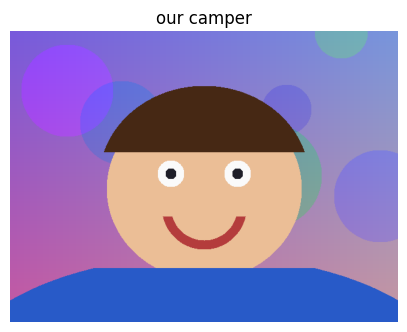

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def load(path):
    '''Load a PNG as a uint8 RGB array with values 0-255.'''
    img = plt.imread(path)
    if img.dtype != np.uint8:              # matplotlib loads PNGs as floats 0-1
        img = (img * 255).round().astype(np.uint8)
    return img[:, :, :3]                   # drop the alpha channel

def show(*imgs, titles=None, gray=False):
    '''Display one or more images side by side.'''
    fig, axes = plt.subplots(1, len(imgs), figsize=(5 * len(imgs), 4))
    axes = np.atleast_1d(axes)
    for i, (ax, im) in enumerate(zip(axes, imgs)):
        ax.imshow(im, cmap="gray" if gray else None, vmin=0, vmax=255)
        ax.axis("off")
        if titles: ax.set_title(titles[i])
    plt.show()

img = load("images/portrait.png")
show(img, titles=["our camper"])

In [2]:
# TODO: print the shape, dtype, ndim, and size of `img`.
print("shape:", img.shape)
print("dtype:", img.dtype)
print("ndim :", img.ndim)
print("size :", img.size)

# Then answer: what do the three numbers in shape mean?
# YOUR ANSWER: shape = ( 480 , 640 , 3 ) means (height, width, channels)

shape: (480, 640, 3)
dtype: uint8
ndim : 3
size : 921600


✅ **Checkpoint 0:** shape `(480, 640, 3)`, dtype `uint8`. A photo is a 3-D array:
`img[row, column, channel]`.

---
## Part 1 · Slicing Surgery ✂️

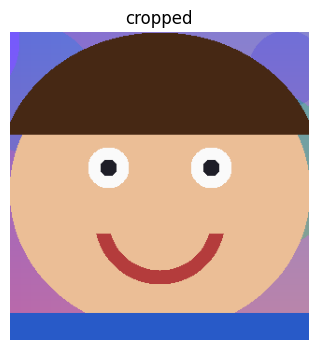

In [3]:
# Exercise 1.1 — CROP: extract just the face
# (roughly rows 90 to 420, columns 160 to 480). No loops!
face = img[90:420, 160:480]
show(face, titles=["cropped"])

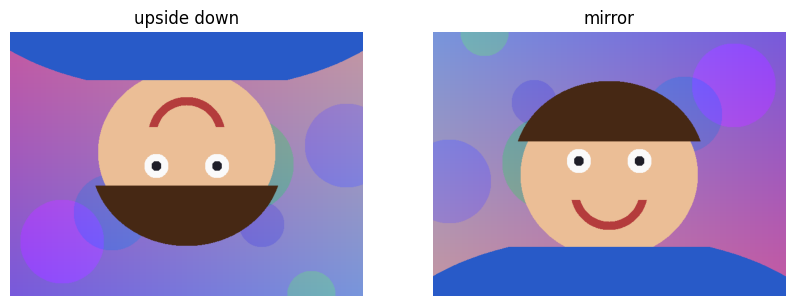

In [4]:
# Exercise 1.2 — FLIPS: using only slicing with negative steps (::-1),
# make an upside-down version and a mirrored version.
upside_down = img[::-1]
mirrored    = img[:, ::-1]
show(upside_down, mirrored, titles=["upside down", "mirror"])

(480, 640)


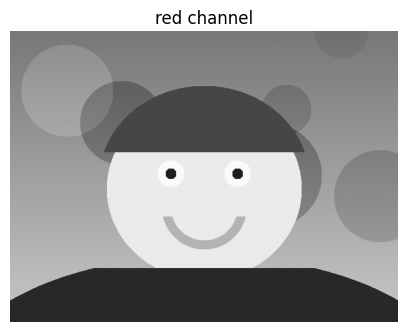

In [5]:
# Exercise 1.3 — CHANNEL X-RAY: extract just the red channel as a 2-D array.
red = img[:, :, 0]
print(red.shape)
show(red, gray=True, titles=["red channel"])

(960, 1280, 3)


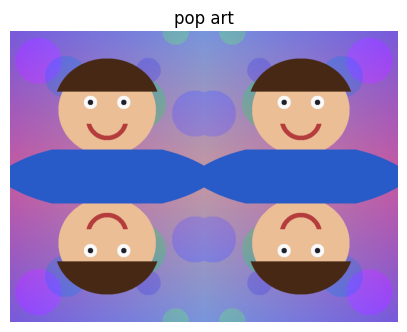

In [7]:
# Exercise 1.4 — WARHOL GRID: ONE image containing a 2x2 grid:
#   top:    original    | mirrored
#   bottom: upside down | upside down AND mirrored
# Hint: np.hstack / np.vstack take a TUPLE of arrays.
warhol = np.vstack((
  np.hstack((img, mirrored)),
  np.hstack((upside_down, upside_down[:, ::-1]))
))
print(warhol.shape)   # should be (960, 1280, 3)
show(warhol, titles=["pop art"])

✅ **Checkpoint 1:** Warhol grid is `(960, 1280, 3)`. **Code check before Part 2.**

---
## Part 2 · Broadcasting Filters 🎨

In [8]:
# THE uint8 TRAP — run this and look carefully.
pixel = np.array([200, 100, 50], dtype=np.uint8)
print("pixel + 100 =", pixel + 100)     # 200 + 100 = ...44?!
# uint8 holds 0..255, so 300 wraps to 44. Rule: float -> math -> clip -> uint8:
img_f = img.astype(np.float64)
print("safe:", np.clip(img_f[0, 0] + 100, 0, 255).astype(np.uint8))

pixel + 100 = [ 44 200 150]
safe: [220 190 255]


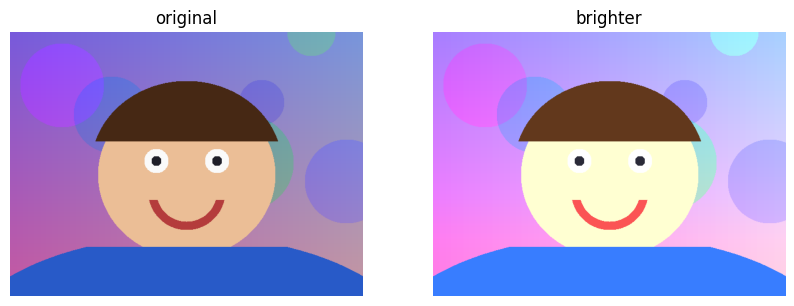

In [10]:
# Exercise 2.1 — BRIGHTNESS: 40% brighter. Multiply img_f by 1.4,
# clip to 0..255, convert back to uint8.
brighter = np.clip(img_f * 1.4, 0, 255).astype(np.uint8)
show(img, brighter, titles=["original", "brighter"])

(480, 640)


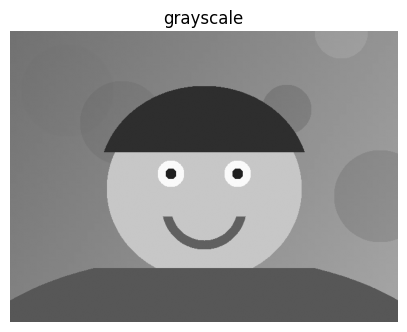

In [12]:
# Exercise 2.2 — GRAYSCALE: real grayscale is a WEIGHTED sum:
#   gray = 0.299*R + 0.587*G + 0.114*B   (eyes love green)
# One line with @:  (480, 640, 3) @ (3,)  ->  (480, 640)
weights = np.array([0.299, 0.587, 0.114])
gray = img @ weights
print(gray.shape)
show(gray, gray=True, titles=["grayscale"])

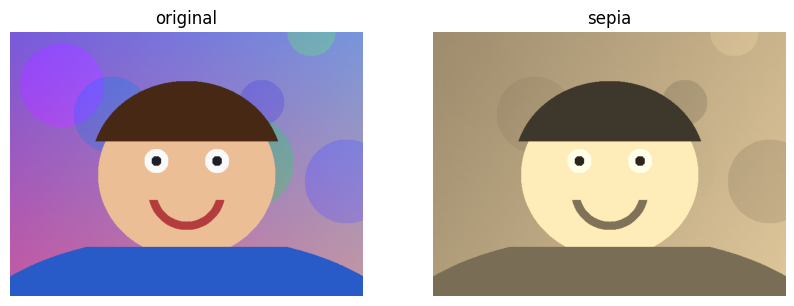

In [13]:
# Exercise 2.3 — SEPIA: every output pixel = 3x3 matrix times input pixel.
sepia_matrix = np.array([[0.393, 0.769, 0.189],
                         [0.349, 0.686, 0.168],
                         [0.272, 0.534, 0.131]])
sepia = np.clip(img_f @ sepia_matrix.T, 0, 255).astype(np.uint8) # TODO: img_f @ sepia_matrix.T, clip, uint8. (Why .T?)
show(img, sepia, titles=["original", "sepia"])

(480, 640) (480, 640)


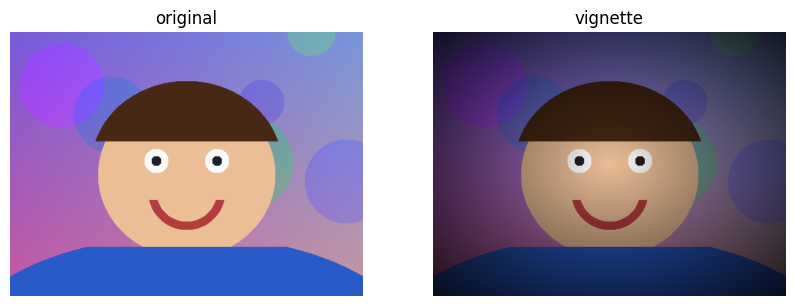

In [14]:
# Exercise 2.4 — VIGNETTE (dark corners). Broadcasting boss level.
#   1. ys = np.linspace(-1, 1, 480) as a COLUMN: shape (480, 1)
#   2. xs = np.linspace(-1, 1, 640) as a ROW:    shape (1, 640)
#   3. dist = np.sqrt(xs**2 + ys**2)  -> broadcasts to (480, 640)!
#   4. fade = np.clip(1 - 0.6 * dist, 0, 1)
#   5. img_f * fade — shapes don't match... np.newaxis to the rescue.
ys   = np.linspace(-1, 1, 480).reshape(-1, 1)  # shape (480, 1)
xs   = np.linspace(-1, 1, 640).reshape(1, -1)  # shape (1, 640)
dist = np.sqrt(xs**2 + ys**2)
fade = np.clip(1 - 0.6 * dist, 0, 1)
vignette = np.clip(img_f * fade[:, :, np.newaxis], 0, 255).astype(np.uint8)
print(dist.shape, fade.shape)
show(img, vignette, titles=["original", "vignette"])

In [15]:
# THE GREAT SPEED RACE 🏁 — why the One Rule exists.
import time
t0 = time.perf_counter()
slow = np.zeros_like(img)
for r in range(img.shape[0]):
    for c in range(img.shape[1]):
        for ch in range(3):
            slow[r, c, ch] = min(int(img[r, c, ch] * 1.4), 255)
t_loop = time.perf_counter() - t0
t0 = time.perf_counter()
fast = np.clip(img.astype(np.float64) * 1.4, 0, 255).astype(np.uint8)
t_np = time.perf_counter() - t0
print(f"triple loop: {t_loop:.3f} s")
print(f"NumPy:       {t_np:.5f} s")
print(f"NumPy is {t_loop / t_np:,.0f}x faster")

triple loop: 1.488 s
NumPy:       0.00805 s
NumPy is 185x faster


✅ **Checkpoint 2:** four filters done, NumPy crushed the loop.

---
## Part 3 · Green-Screen Movie Magic 🎬
Hollywood compositing = **boolean array indexing**.

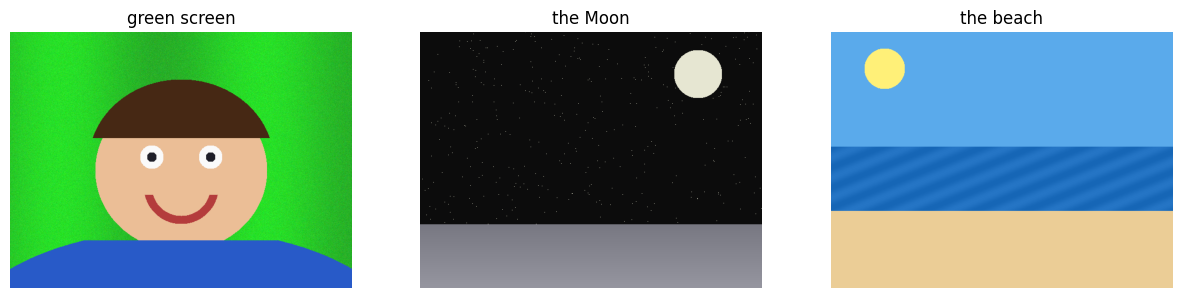

In [16]:
gs    = load("images/greenscreen.png")
moon  = load("images/background_moon.png")
beach = load("images/background_beach.png")
show(gs, moon, beach, titles=["green screen", "the Moon", "the beach"])

In [20]:
# Exercise 3.1 — SCOUT: print mean R, G, B of the top-left 50x50 corner
# (pure screen) so you know what "green screen green" is numerically.
top_left = img[:50, :50]
print(f"R: {np.mean(top_left[:, :, 0])}")
print(f"G: {np.mean(top_left[:, :, 1])}")
print(f"B: {np.mean(top_left[:, :, 2])}")

R: 124.488
G: 91.032
B: 217.914


(480, 640) bool


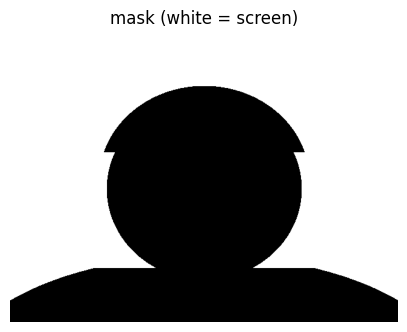

In [25]:
# Exercise 3.2 — MASK: a boolean array, True where the pixel is green-screen.
# Combine TWO conditions with np.logical_and (from the Week 5 slides!),
# using your stats from 3.1 to pick the thresholds.
mask = np.logical_and(gs[:, :, 1] > 90, gs[:, :, 0] < 130)  # TODO: np.logical_and(green channel > ___, red channel < ___)
print(mask.shape, mask.dtype)
show(mask * 255, gray=True, titles=["mask (white = screen)"])

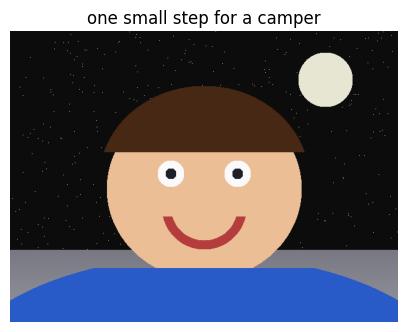

In [31]:
# Exercise 3.3 — COMPOSITE with np.where(condition, if_true, if_false).
# Shape puzzle: mask is (480,640), images are (480,640,3)...
on_moon = np.where(mask[:, :, np.newaxis], moon, gs)
show(on_moon, titles=["one small step for a camper"])

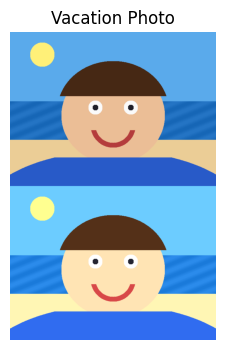

In [34]:
# Exercise 3.4 — VACATION PHOTO: composite onto the beach, apply your
# favorite Part-2 filter on top, np.hstack a side-by-side postcard.
on_moon = np.where(mask[:, :, np.newaxis], beach, gs)
brighter = np.clip(on_moon * 1.2, 0, 255).astype(np.uint8)
res = np.vstack((
  on_moon,
  brighter
))
show(res, titles=["Vacation Photo"])

✅ **Checkpoint 3:** camper on the Moon, clean edges. **Code check.**

---
## Part 4 · Photo Forensics 🕵️ — the challenge tier
A hillside photo was submitted as evidence... but the original surfaced too.
The forger made **two** edits. Find both — *with statistics, not eyeballs*.

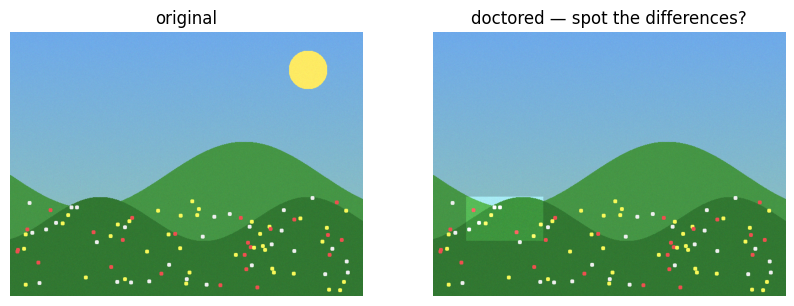

In [35]:
orig = load("images/scene_original.png").astype(np.int64)   # we need negatives!
doc  = load("images/scene_doctored.png").astype(np.int64)
show(orig, doc, titles=["original", "doctored — spot the differences?"])

max difference: 355


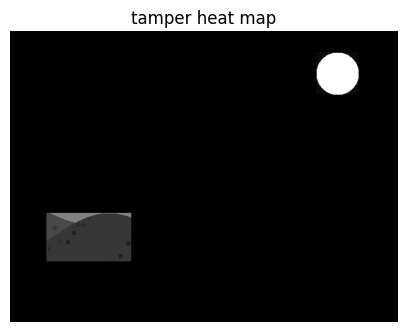

In [37]:
# Exercise 4.1 — DIFFERENCE MAP: per-pixel absolute difference, summed over
# channels -> 2-D tamper heat map. (Why int64 first? What's 10 - 200 in uint8?)
diff = np.abs(orig.astype(np.int64) - doc.astype(np.int64)).sum(axis=2)
print("max difference:", diff.max())
show(diff, gray=True, titles=["tamper heat map"])

In [60]:
# Exercise 4.2 — LOCATE: np.argwhere(diff > 30) gives (N, 2) [row, col]
# coordinates. Report min/max row and col — then split the coords to report
# EACH tampered region separately.
coords = np.argwhere(diff > 30)
print("rows", coords[:, 0].min(), "to", coords[:, 0].max())
print("cols", coords[:, 1].min(), "to", coords[:, 1].max())

print("-----")

mid = 240
coords_split1 = coords[coords[:, 0] < mid]
coords_split2 = coords[coords[:, 0] >= mid]
print("Area1 : rows", coords_split1[:, 0].min(), "to", coords_split1[:, 0].max(), "cols", coords_split1[:, 1].min(), "to", coords_split1[:, 1].max())
print("Area2 : rows", coords_split2[:, 0].min(), "to", coords_split2[:, 0].max(), "cols", coords_split2[:, 1].min(), "to", coords_split2[:, 1].max())

rows 36 to 379
cols 60 to 574
-----
Area1 : rows 36 to 104 cols 506 to 574
Area2 : rows 300 to 379 cols 60 to 199


In [82]:
# Exercise 4.3 — CHARACTERIZE: for the field region, compare doc vs orig with
# np.mean. The forger applied one simple math operation — which, with what number?
# Hint: try the RATIO of the means.
print(np.mean(orig[36:104, 506:574] / doc[36:104, 506:574]))

1.2710526852213864


✅ **Checkpoint 4:** cloned sky patch found AND ×1.25 brightening proven. Case closed. 🎉

---
## 🏆 Bonus Round (for the fearless)

In [92]:
# BONUS A — SECRET MESSAGE: images/secret.png looks identical to the
# portrait, but a spy wrote a message into it. Remember: text is numbers too —
# every character has an ASCII code (chr(78) is 'N', ord('N') is 78).
# The spy replaced the RED values of the first pixels in the TOP ROW with
# the ASCII codes of the message, ending with a 0.
#   1. Slice out those values:  secret[0, :60, 0]
#   2. Print them — do you see numbers in the letter range (65-90, 32)?
#   3. Convert to text: "".join(chr(v) for v in ...) and stop at the 0.
secret = load("images/secret.png")
codes = secret[0, :60, 0]
print("raw codes:", codes)

end = list(codes).index(0)
print("message:", "".join(chr(v) for v in codes[:end]))

raw codes: [ 78  85  77  80  89  32  87  73  90  65  82  68  83  32  82  85  76  69
   0 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120
 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120 120
 120 120 120 120 120 120]
message: NUMPY WIZARDS RULE


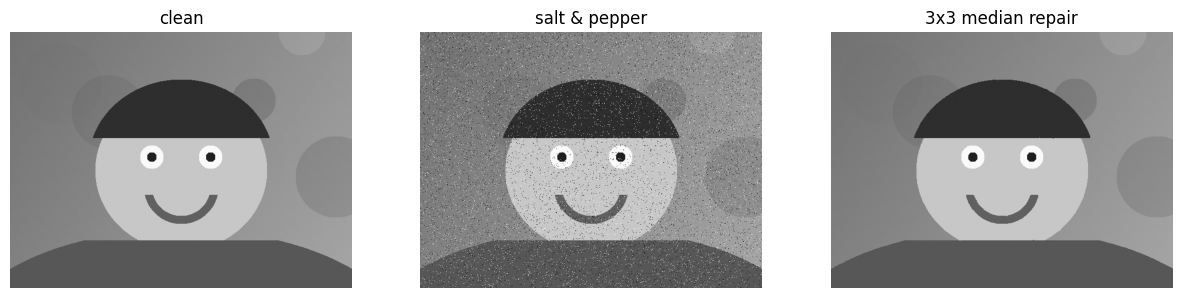

In [110]:
# BONUS B — NOISE ATTACK & REPAIR: add salt & pepper noise to a grayscale
# copy (np.random.random to pick ~4% of pixels; set some 0, some 255), then
# repair with a 3x3 MEDIAN filter — build 9 shifted copies by slicing (a loop
# over the 9 OFFSETS is allowed), np.stack, np.median(axis=0).
g = img_f @ np.array([0.299, 0.587, 0.114])

np.random.seed(0)
r = np.random.random(g.shape)
pepper = r < 0.02
salt   = r > 0.98
noisy  = np.where(pepper, 0, np.where(salt, 255, g))

H, W = g.shape
pad = np.pad(noisy, 1, mode="edge")
windows = np.stack([pad[dy:dy + H, dx:dx + W] for dy in range(3) for dx in range(3)])

repaired = np.median(windows, axis=0)

show(g, noisy, repaired, gray=True,
     titles=["clean", "salt & pepper", "3x3 median repair"])

---
## 🚀 Open-Ended Challenges — choose your own adventure
No TODO scaffolding from here on. Pick any challenge, design your own approach,
and be ready to explain **why** your solution works, not just that it does.
⭐ = tough, ⭐⭐ = very tough, ⭐⭐⭐ = show us something we haven't seen.
Rules still apply: no pixel loops.

In [ ]:
# CHALLENGE 1 ⭐ — LAUNCH YOUR FILTER BRAND
# Invent a signature filter with a NAME, combining at least THREE distinct
# operations (tint, vignette, contrast, grain, fade, channel swap, ...).
# Examples to beat: "Michigan Winter" (cold tint + heavy vignette + low
# contrast), "Golden Hour" (warm tint + soft fade + gentle grain).
# Requirements: one function  my_filter(img) -> uint8 image,  applied to BOTH
# the portrait and your green-screen composite. Judged on: originality,
# clean code, and whether your neighbor can guess the name from the look.

In [ ]:
# CHALLENGE 2 ⭐ — PENCIL SKETCH (edge detection from scratch)
# An "edge" is where neighboring pixel values change fast. You can measure
# change with SHIFTED SLICES — no loops:
#     horizontal change: gray[:, 1:] - gray[:, :-1]
#     vertical change:   gray[1:, :] - gray[:-1, :]
# Build an edge-strength map (careful: shapes differ by one — crop to match!),
# then turn it into a pencil sketch: white paper, dark lines.
# Open questions YOU decide: how to combine the two directions? what
# threshold? invert with 255 - x? Can you overlay the sketch on the photo?

In [ ]:
# CHALLENGE 3 ⭐⭐ — PRIVACY MODE (selective pixelation)
# News crews pixelate faces. Two sub-problems, both yours to design:
#   (a) Pixelate: shrink each k x k block to its average color. The famous
#       reshape trick does it with ZERO loops:
#         img.reshape(H//k, k, W//k, k, 3).mean(axis=(1, 3))
#       ...then blow it back up (np.repeat, twice, on different axes).
#   (b) Selective: pixelate ONLY a region (the face) while the rest stays
#       sharp. You already know the masking tools.
# Your choices: block size k, region shape (rectangle? ellipse using the
# circle-equation trick?), soft or hard boundary.

In [ ]:
# CHALLENGE 4 ⭐⭐ — AUTO GREEN SCREEN (no magic numbers)
# Your Part-3 mask used hand-tuned thresholds. Real software auto-detects.
# Write  auto_composite(subject, background)  that works on ANY solid-ish
# backdrop color — green, blue, hot pink — with NO hardcoded thresholds:
#   1. Estimate the backdrop color from the image itself (hint: which pixels
#      are almost certainly backdrop? Think borders. Think np.median.)
#   2. Compute each pixel's DISTANCE to that color in 3-D color space
#      (one np.linalg.norm or a sqrt-of-sums — broadcasting again).
#   3. Threshold the distance — but derive the threshold from the data too
#      (np.percentile of the border distances?).
# Test: it must work on greenscreen.png UNCHANGED, then still work if you
# swap the green for another color (hint: gs[:, :, [2, 1, 0]]).

In [ ]:
# CHALLENGE 5 ⭐⭐⭐ — FORENSICS WITHOUT THE ORIGINAL
# In Part 4 you had the original for comparison. Real forensic analysts don't.
# Using ONLY scene_doctored.png, find evidence of the clone-stamp edit.
# One powerful idea: the pasted patch is an EXACT COPY of another region, so
# somewhere two patches match far too perfectly (real photos have unique
# sensor noise everywhere — that's why the photo is grainy!).
# Design your own detector. Possible directions (pick one, or invent):
#   - shift-and-compare: subtract the image from a SHIFTED copy of itself
#     (slicing, or np.roll). The result is suspiciously tiny where the clone
#     and its source align. What shift? Can you SEARCH over shifts? (A loop
#     over candidate shifts is allowed — hypotheses, not pixels.)
#   - local texture: compute a block std-dev map via the reshape trick from
#     Challenge 3 — cloned sky vs real sky may differ from surroundings.
# Deliverable: a heat map + a one-paragraph "expert testimony" explaining
# your evidence. Partial detections welcome — argue what you found.

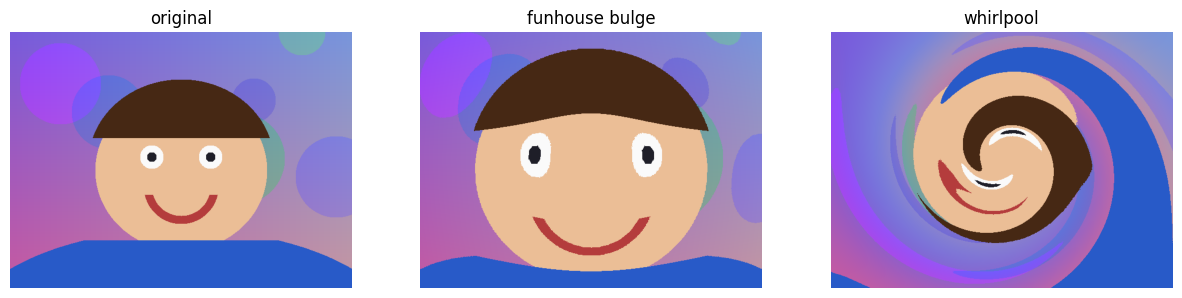

In [116]:
# CHALLENGE 6 ⭐⭐⭐ — FUNHOUSE MIRROR (warp reality with fancy indexing)
# Integer array indexing (from the slides!) lets you build a NEW image by
# telling NumPy which source pixel to grab for every output pixel:
#     rows = np.arange(480)[:, np.newaxis]        # (480, 1)
#     cols = np.arange(640)[np.newaxis, :]        # (1, 640)
#     copy = img[rows, cols]                      # boring... so far
# Now BEND the coordinates before indexing. A wavy mirror:
#     wavy_cols = (cols + 25 * np.sin(rows / 30)).astype(int) % 640
#     warped = img[rows, wavy_cols]
# Your mission: invent at least TWO of your own distortions. Ideas to riff on:
# a funhouse bulge (stretch coordinates near the center), a whirlpool (rotate
# by an angle that grows with distance from center — you have dist from the
# vignette!), a glitch effect (shift each row by a random amount), underwater
# ripples (waves in BOTH axes)... Explain the coordinate math for each.

H, W = img.shape[:2]
rows = np.arange(H)[:, np.newaxis]
cols = np.arange(W)[np.newaxis, :]

cy, cx = (H - 1) / 2, (W - 1) / 2
dy, dx = rows - cy, cols - cx
r  = np.sqrt(dy**2 + dx**2)
th = np.arctan2(dy, dx)
r_max = np.sqrt(cy**2 + cx**2)
r_n = r / r_max

def sample(src_rows, src_cols):
    rr = np.clip(np.rint(src_rows), 0, H - 1).astype(int)
    cc = np.clip(np.rint(src_cols), 0, W - 1).astype(int)
    return img[rr, cc]

src_r = r_max * r_n**1.5
bulge = sample(cy + src_r * np.sin(th), cx + src_r * np.cos(th))

th_twist = th + 10 * (1 - r_n)**2
whirl = sample(cy + r * np.sin(th_twist), cx + r * np.cos(th_twist))

show(img, bulge, whirl, titles=["original", "funhouse bulge", "whirlpool"])


### How you'll be judged (all challenges)
1. **It runs** and obeys the One Rule.
2. **You can explain it** — every line, every threshold, every shape.
3. **You made choices** — and can say what you tried that *didn't* work.
Nobody finishes all six. Depth beats coverage. 🏔️

---
## 🖼️ Ship It — Gallery Walk
Compose one stacked image of your three favorite creations (`np.hstack`/`np.vstack`),
then `plt.imsave("my_exhibit.png", exhibit)`.

**Used today:** shape & dtype · slicing · negative strides · stacking · broadcasting ·
`np.newaxis` · `@` · ufuncs & `np.clip` · `np.logical_and` · boolean masks & `np.where` ·
integer (fancy) indexing · `np.argwhere` · `np.mean`/`np.median` · `np.random`

You didn't just learn NumPy today. You built Photoshop. 🧪

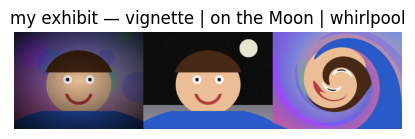

In [ ]:
moon_shot = np.where(mask[:, :, np.newaxis], moon, gs)
exhibit = np.hstack((vignette, moon_shot, whirl))
plt.imsave("my_exhibit.png", exhibit)
show(exhibit, titles=["my exhibit — vignette | on the Moon | whirlpool"])
